<a href="https://colab.research.google.com/github/macafraga/iele756-region-xx/blob/main/iele756_grupo7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# ruta Drive
ruta_censo = "/content/drive/MyDrive/Ramo_IELE756/personas_censo2024.parquet"

persona = pd.read_parquet(
    ruta_censo,
    columns=["region", "comuna", "sexo", "edad",
             "p27_nacionalidad", "p27_nacionalidad_rec",
             "escolaridad", "sit_fuerza_trabajo"],
)
print (f"Total personas: {len(persona):,}")
print (persona.dtypes)

Total personas: 18,480,432
region                    int32
comuna                    int32
sexo                      int32
edad                      int32
p27_nacionalidad          int32
p27_nacionalidad_rec      int32
escolaridad               int32
sit_fuerza_trabajo      float64
dtype: object


In [ ]:
print (persona.shape) #ver el total de filas
persona.info #ver si hay valores nulos
persona.head(10) #mostrar las primeras 10 filas


(18480432, 8)


,region,comuna,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,escolaridad,sit_fuerza_trabajo
0,5,5802,2,80,1,1,17,3.0
1,5,5802,1,52,1,1,14,1.0
2,5,5802,2,45,1,1,12,1.0
3,5,5802,2,8,1,1,2,NaN
4,4,4303,1,69,1,1,12,3.0
5,4,4303,2,65,1,1,12,3.0
6,4,4303,1,58,1,1,15,1.0
7,11,11202,2,-66,-66,1,8,1.0
8,11,11202,1,-66,-66,1,5,1.0
9,11,11202,1,-66,-66,1,3,NaN


In [ ]:
# region asignada numero 13 (Metropolitana)
metropolitana = persona[persona["region"] == 13]
print(f"Metropolitana: {len(metropolitana):,} personas ")

Metropolitana: 7,400,741 personas 


In [ ]:
#NACIONALIDAD
#Códigos : 1=chilenos , 2=chileno+otro , 3=extranjero , -99=NR(datos faltantes)
print(metropolitana["p27_nacionalidad_rec"].value_counts())

foreign = metropolitana["p27_nacionalidad_rec"] \
.value_counts(normalize=True)
print(f"% extranjeros: {foreign.get('Extranjero', 0):.1%}")

p27_nacionalidad_rec
 1     6446621
 2      904819
-99      49301
Name: count, dtype: int64
% extranjeros: 0.0%


In [ ]:
#ENO (Enfermedades de Notificación Obligatoria)
import pandas as pd

# Ajusta la ruta a tu carpeta de Drive
ruta_eno = "/content/drive/MyDrive/Ramo_IELE756/20241218_base_eno_final.csv"

eno = pd.read_csv(ruta_eno, sep=";", encoding="utf-8-sig")

print(f"Total de filas: {len(eno):,}") # Deberían ser ~333,000
print(eno.columns.tolist())

/tmp/ipykernel_152/273243847.py:7: DtypeWarning: Columns (6,11,12,13,14,15,16,17,18,19,20,22,23,24,25,26,27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  eno = pd.read_csv(ruta_eno, sep=";", encoding="utf-8-sig")


Total de filas: 333,300
['etapa_clinica', 'region', 'seremi', 'nacionalidad', 'cie_10_diagnostico', 'diagnostico', 'Autóctono', 'anho_notificacion', 'ENO', 'pueblo_indigena', 'nombre_instruccion', 'presenta_sintomas', 'sintomas', 'consumo_agua_no_potable', 'antecedente_teniasis', 'imagenologia', 'manifestaciones', 'existe_coinfeccion', 'via_transmision', 'n_parejas_sexuales', 'uso_preservativo', 'pais_contagio', 'paciente_inmunosuprimido', 'vih', 'pareja', 'exantema_mpox', 'factores_exposicion', 'neumonia', 'contacto_aves', 'genotipo_1', 'recuento_linfocitos', 'clasificacion_final_vih', 'etapa_vih_sida', 'hospitalizacion', 'nombre_primer_sintoma', 'SeroGrupo', 'sexo', 'grupo_edad', 'codigo_comuna_residencia']


In [ ]:
# Filtrar ENO a "Región Metropolitana de Santiago"
eno_met = eno[eno["region"] == "Región Metropolitana de Santiago"]
print(f"Metropolitana: {len(eno_met):,}")

Metropolitana: 126,669


In [ ]:
eno_met["ENO"].value_counts().head(10)

,count
ENO,
Sifilis,40928
VIH,29097
Parotiditis,15493
Infección gonocócica,8766
Hepatitis B,7565
Coqueluche,6455
Hepatitis A,5146
Hepatitis C,4678
Chagas,3286


In [ ]:
# Filtrar ENO a "Región del Ñuble"
eno_nub = eno[eno["region"] == "Región del Ñuble"]
print(f"Ñuble: {len(eno_nub):,}")

Ñuble: 2,818


In [ ]:
eno_nub["ENO"].value_counts().head(10)

,count
ENO,
Sifilis,793
Parotiditis,765
VIH,354
Hidatidosis (Equinococosis),220
Hepatitis A,161
Infección gonocócica,103
Síndrome Pulmonar por Hantavirus,91
Hepatitis B,74
Neumococo,50


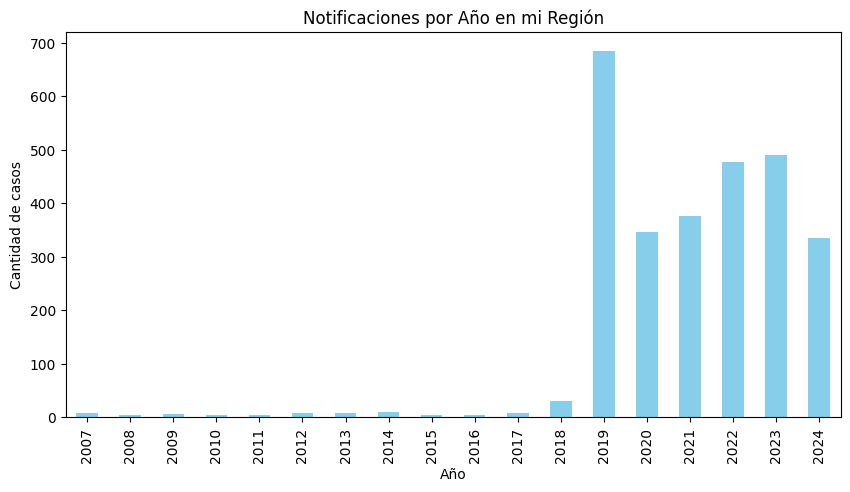

In [ ]:
import matplotlib.pyplot as plt

# Contar y ordenar por año
conteo_anual = eno_nub["anho_notificacion"].value_counts().sort_index()

# Crear el gráfico
conteo_anual.plot(kind="bar", color="skyblue", figsize=(10, 5))
plt.title("Notificaciones por Año en mi Región")
plt.xlabel("Año")
plt.ylabel("Cantidad de casos")
plt.show()

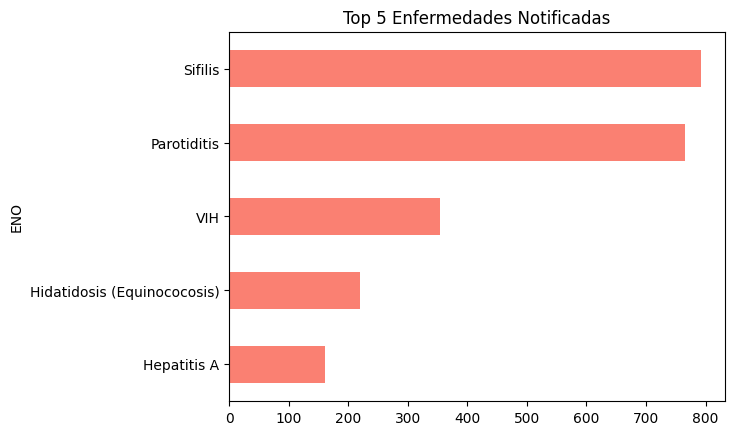

In [ ]:
top_enfermedades = eno_nub["ENO"].value_counts().head(5)

top_enfermedades.plot(kind="barh", color="salmon")
plt.title("Top 5 Enfermedades Notificadas")
plt.gca().invert_yaxis() # Para que la #1 quede arriba
plt.show()

In [ ]:
eno_nub["nacionalidad"].value_counts()

,count
nacionalidad,
Chile,2549
Extranjero,168
Desconocido,101


In [ ]:
#cuál es la enfermedad más común en Metropolitana para extranjeros ?
eno_met[eno_met["nacionalidad"] == "Extranjero"] \
["ENO"].value_counts().head()

,count
ENO,
VIH,7974
Hepatitis B,6545
Sifilis,6202
Infección gonocócica,654
Parotiditis,544


In [ ]:
# Cuántas comunas únicas hay en ENO Metropoitana?
eno_met["codigo_comuna_residencia"].nunique()

280

In [ ]:
import pandas as pd

# Define las columnas que se necesitan
cols = ["COMUNA", "NACIONALIDAD", "SEXO", "DIAGNOSTICO1",
        "FECHA_INGRESO", "FECHAALTA", "IR_29301_SEVERIDAD", "IR_29301_COD_GRD"]

# Ruta al archivo .txt en Drive
ruta_grd = "/content/drive/MyDrive/Ramo_IELE756/GRD_PUBLICO_2024.txt"

# Cargar el archivo
grd = pd.read_csv(ruta_grd, sep="|", usecols=cols, low_memory=False, encoding="latin-1")

print(f"Total de egresos cargados: {len(grd):,}")

Total de egresos cargados: 1,085,813


In [ ]:
# Filtro de egresos hospitalarios en la región Metropolitana
comunas_metropolitana = ["SANTIAGO", "CONCHALÍ", "HUECHURABA", "INDEPENDENCIA", "QUILICURA",
    "RECOLETA", "RENCA", "LAS CONDES", "LO BARNECHEA", "VITACURA",
    "LA REINA", "MACUL", "ÑUÑOA", "PROVIDENCIA", "PEÑALOLÉN",
    "LA FLORIDA", "LA GRANJA", "EL BOSQUE", "LA CISTERNA", "LA PINTANA",
    "SAN RAMÓN", "LO ESPEJO", "PEDRO AGUIRRE CERDA", "SAN JOAQUÍN",
    "SAN MIGUEL", "CERRILLOS", "ESTACIÓN CENTRAL", "MAIPÚ", "PUDAHUEL",
    "QUINTA NORMAL", "CERRO NAVIA", "LO PRADO", "PUENTE ALTO", "PIRQUE",
    "SAN JOSÉ DE MAIPO", "COLINA", "LAMPA", "TILTIL", "SAN BERNARDO",
    "BUIN", "CALERA DE TANGO", "PAINE", "MELIPILLA", "ALHUÉ",
    "CURACAVÍ", "MARÍA PINTO", "SAN PEDRO", "TALAGANTE", "EL MONTE",
    "ISLA DE MAIPO", "PADRE HURTADO", "PEÑAFLOR"]
grd_met = grd[grd["COMUNA"].isin(comunas_metropolitana)]
print(f"Metropolitana: {len(grd_met):,}")

Metropolitana: 332,717


In [ ]:
cie10 = pd.read_excel("/content/drive/MyDrive/Ramo_IELE756/CIE-10.xlsx",
sheet_name="CIE 10")
grd_met = grd_met.merge(
cie10[["Código", "Descripción", "Capítulo"]],
left_on="DIAGNOSTICO1", right_on="Código",
how="left")

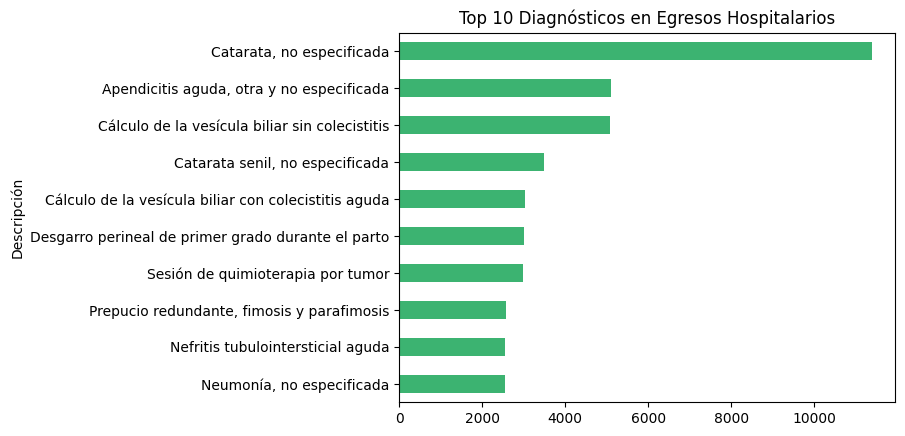

In [ ]:
# Top 10 diagnosticos
top_diagnosticos = grd_met["Descripción"].value_counts().head(10)

top_diagnosticos.plot(kind="barh", color="mediumseagreen")
plt.title("Top 10 Diagnósticos en Egresos Hospitalarios")
plt.gca().invert_yaxis()
plt.show()

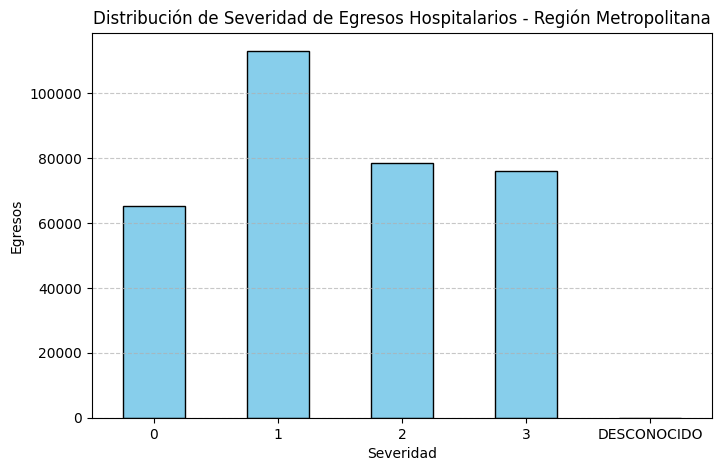

In [ ]:
import matplotlib.pyplot as plt

# Contar la frecuencia de cada nivel de severidad en la RM
# Usamos sort_index() para que los niveles (1, 2, 3, 4) aparezcan en orden
dist_severidad = grd_met["IR_29301_SEVERIDAD"].value_counts().sort_index()

# Crear el gráfico de barras
plt.figure(figsize=(8, 5))
dist_severidad.plot(kind="bar", color="skyblue", edgecolor="black")

# Personalizar el gráfico
plt.title("Distribución de Severidad de Egresos Hospitalarios - Región Metropolitana")
plt.xlabel("Severidad") # 0 = Sin gravedad, 1 = Menor, 2 = Moderada, 3 = Mayor
plt.ylabel("Egresos")
plt.xticks(rotation=0) # Mantener los números horizontales
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.show()

# Se observan muchos casos de egresos en un nivel menor, pero hay se observa que existe uso considerable de recursos